# Laboratório IAAut — Aprendizagem Não Supervisionada


## Imports e seed

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NAO MODIFICAR A SEED
# flag = 0 --> random
# flag = 1 --> km++
np.random.seed(555)

## Leitura e normalização dos dados

In [4]:
df_train = pd.read_pickle('Xtrain.pkl')

# todas as poses de todas as sequências numa única matriz: (8374, 66)
X = np.concatenate(df_train['Skeleton_Sequence'].to_numpy())
print(X.shape)

# Normalização dos dados - centrar + escalamento (recomendado e crítico para o PCA)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

(8374, 66)


## Parte I — k-means

### 1. Implementação

In [7]:
def kminit(X, K, flag):
    # Inicialização - aleatória (flag = 0) ou k-means++ (flag = 1)
    # A inicialização do primeiro centróide é fixa
    N = X.shape[0]
    C = []
    init_centr_idx = np.random.randint(N)
    C.append(X[init_centr_idx])

    if flag == 0:   # random
        idx = np.random.choice(N, K - 1, replace=False)
        while init_centr_idx in idx:   # caso raro --> repetiu o primeiro
            idx = np.random.choice(N, K - 1, replace=False)
        C.extend(X[idx])

    else:           # k-means++
        for _ in range(K - 1):
            C_atual = np.array(C)
            M = np.zeros((N, len(C_atual)))

            # distância ao quadrado de cada pose a cada centroide já escolhido
            for k in range(len(C_atual)):
                M[:, k] = np.sum((X - C_atual[k])**2, axis=1)

            # distância de cada pose ao centroide MAIS PRÓXIMO: (N,)
            d2 = np.min(M, axis=1)

            # probabilidade proporcional a d²
            prob = d2 / np.sum(d2)

            new_idx = np.random.choice(N, p=prob)
            C.append(X[new_idx])

    return np.array(C)

In [6]:
def kmeans_custo(X, C, s):
    # Calcula a função de custo do k-means
    centr_point = C[s]                                   # centroide de cada pose: (N, 66)
    dist_eucl = np.sum((X - centr_point)**2, axis=1)     # distância ao quadrado de cada pose ao seu centroide: (N,)
    total_cost = np.sum(dist_eucl)
    return total_cost

In [5]:
def kmeans(X, K, flag):
    # Aplica o algoritm k-means a matriz de dados X.
    C = kminit(X,K,flag)
    prev_cost = np.inf
    N = X.shape[0]

    while True:
        M = np.zeros((N, K))

        for k in range(K):
            M[:, k] = np.sum((X - C[k])**2, axis=1)     # distância ao quadrado de cada pose ao centroide k: (N,)

        s = np.argmin(M, axis=1)                        # para cada pose, o centroide mais próximo

        total_cost = kmeans_custo(X, C, s)

        # Comparacao dos custos
        if prev_cost - total_cost < 1e-6:
            break
        prev_cost = total_cost

        # Atualizacao dos centroides
        for k in range(K):
            cluster = X[s == k]
            if len(cluster) > 0:
                C[k] = np.mean(cluster, axis=0)

    return C, s

### 2. Selecionar o número de centróides e inicialização

#### R2.a) Inicialização aleatória — mínimo de 10 execuções por K

In [10]:
Ks = list(range(1, 21))
n_runs = 10

custos_a = np.zeros((len(Ks), n_runs))   # linha = K, coluna = execução
for i, K in enumerate(Ks):
    for r in range(n_runs):
        C, s = kmeans(X_norm, K, 0)
        custos_a[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

min_random = np.min(custos_a, axis=1)

K = 1 feito
K = 2 feito
K = 3 feito
K = 4 feito
K = 5 feito
K = 6 feito
K = 7 feito
K = 8 feito
K = 9 feito
K = 10 feito
K = 11 feito
K = 12 feito
K = 13 feito
K = 14 feito
K = 15 feito
K = 16 feito
K = 17 feito
K = 18 feito
K = 19 feito
K = 20 feito


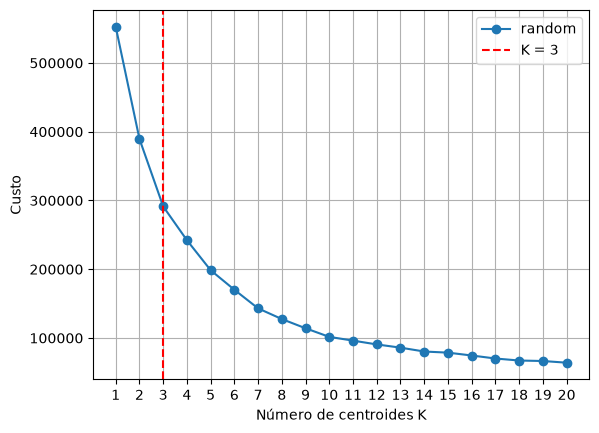

Descidas entre K consecutivos: [163152.20324556  98213.76840042  49089.20031706  43662.09435672
  28416.73250843  27087.68068589  15542.88569355  13395.5532525
  12508.2611849    5444.81690773   5522.00069973   4698.65253052
   5622.07978255   1634.23505552   4154.86687663   4371.54608174
   2934.33183894    707.06166819   2451.16671512]
Variação do declive: [64938.43484514 49124.56808336  5427.10596033 15245.36184829
  1329.05182254 11544.79499235  2147.33244104   887.2920676
  7063.44427717   -77.183792     823.34816922  -923.42725203
  3987.84472703 -2520.63182111  -216.67920511  1437.2142428
  2227.27017075 -1744.10504693]


In [11]:
plt.plot(Ks, min_random, 'o-', label='random')
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2a.png', dpi=150)
plt.show()

descidas = -np.diff(min_random)
print("Descidas entre K consecutivos:", descidas)
print("Variação do declive:", -np.diff(descidas))

#### R2.b) Inicialização k-means++ — mínimo de 10 execuções por K

In [11]:
custos_b = np.zeros((len(Ks), n_runs))
for i, K in enumerate(Ks):
    for r in range(n_runs):
        C, s = kmeans(X_norm, K, 1)
        custos_b[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

min_pp = np.min(custos_b, axis=1)

K = 1 feito
K = 2 feito
K = 3 feito
K = 4 feito
K = 5 feito
K = 6 feito
K = 7 feito
K = 8 feito
K = 9 feito
K = 10 feito
K = 11 feito
K = 12 feito
K = 13 feito
K = 14 feito
K = 15 feito
K = 16 feito
K = 17 feito
K = 18 feito
K = 19 feito
K = 20 feito


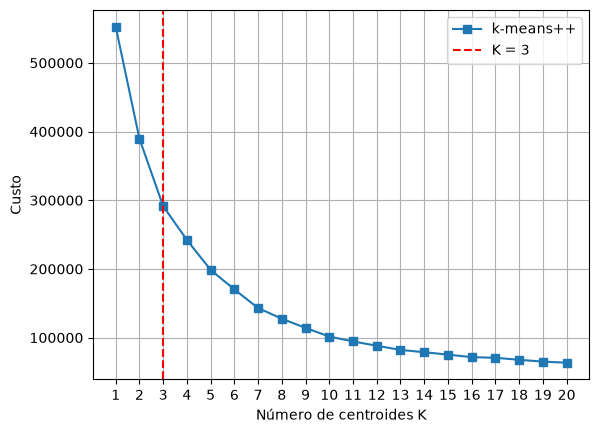

Descidas entre K consecutivos: [163152.20324556  98213.76840042  49089.20031706  43662.06920944
  28416.11992368  27088.31841794  15541.88155771  13398.25601175
  12545.3114046    7126.01237589   6246.78142284   6118.35323529
   3315.58811849   3535.55327122   3671.22341757    910.82287306
   2970.32509982   2638.4839625    1553.64264193]
Variação do declive: [64938.43484514 49124.56808336  5427.13110762 15245.94928576
  1327.80150574 11546.43686022  2143.62554596   852.94460715
  5419.29902871   879.23095305   128.42818755  2802.7651168
  -219.96515274  -135.67014635  2760.40054451 -2059.50222675
   331.84113732  1084.84132057]


In [12]:
plt.plot(Ks, min_pp, 's-', label='k-means++')
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2b.png', dpi=150)
plt.show()

descidas = -np.diff(min_pp)
print("Descidas entre K consecutivos:", descidas)
print("Variação do declive:", -np.diff(descidas))

#### R2.c) 20 execuções por K — média e desvio padrão

In [13]:
n_runs_c = 20

custos_random = np.zeros((len(Ks), n_runs_c))
custos_pp     = np.zeros((len(Ks), n_runs_c))

for i, K in enumerate(Ks):
    for r in range(n_runs_c):
        C, s = kmeans(X_norm, K, 0)                   # random
        custos_random[i, r] = kmeans_custo(X_norm, C, s)

        C, s = kmeans(X_norm, K, 1)                   # k-means++
        custos_pp[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

K = 1 feito
K = 2 feito
K = 3 feito
K = 4 feito
K = 5 feito
K = 6 feito
K = 7 feito
K = 8 feito
K = 9 feito
K = 10 feito
K = 11 feito
K = 12 feito
K = 13 feito
K = 14 feito
K = 15 feito
K = 16 feito
K = 17 feito
K = 18 feito
K = 19 feito
K = 20 feito


In [1]:
# Para refazer o gráfico sem voltar a correr tudo:
# custos_random = np.load('custos_R2c_random.npy')
# custos_pp     = np.load('custos_R2c_pp.npy')

media_random = np.mean(custos_random, axis=1)
std_random   = np.std(custos_random, axis=1)
media_pp     = np.mean(custos_pp, axis=1)
std_pp       = np.std(custos_pp, axis=1)

plt.errorbar(Ks, media_random, yerr=std_random, fmt='o-', capsize=4, label='random')
plt.errorbar(Ks, media_pp, yerr=std_pp, fmt='s-', capsize=4, label='k-means++')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo médio')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2c.png', dpi=150)
plt.show()

for i, K in enumerate(Ks):
    print(f"K={K:2d}  random: {media_random[i]:9.0f} ± {std_random[i]:7.0f}   "
          f"km++: {media_pp[i]:9.0f} ± {std_pp[i]:7.0f}")

NameError: name 'np' is not defined

### 3. Visualização

#### R3.a) Centroides do melhor modelo (K = 3, k-means++, melhor de 10 execuções)
p[a,b] --> Acede ao valor da matriz com estas coordenadas


In [ ]:
CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),      # cara
    (11,12),(11,23),(12,24),(23,24),                              # tronco
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),              # braço esquerdo
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),              # braço direito
    (23,25),(25,27),(27,29),(27,31),(29,31),                      # perna esquerda
    (24,26),(26,28),(28,30),(28,32),(30,32),                      # perna direita
]

def desenhar_pose(ax, pose, title):
    p = pose.reshape(33, 2)                  # 33 marcadores × (u, v)
    for a, b in CONNECTIONS:
        ax.plot([p[a, 0], p[b, 0]], [p[a, 1], p[b, 1]], 'b-')
    ax.scatter(p[:, 0], p[:, 1], c='red', s=15, zorder=3)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title)

291318.02835401817 [1173 6369  832]


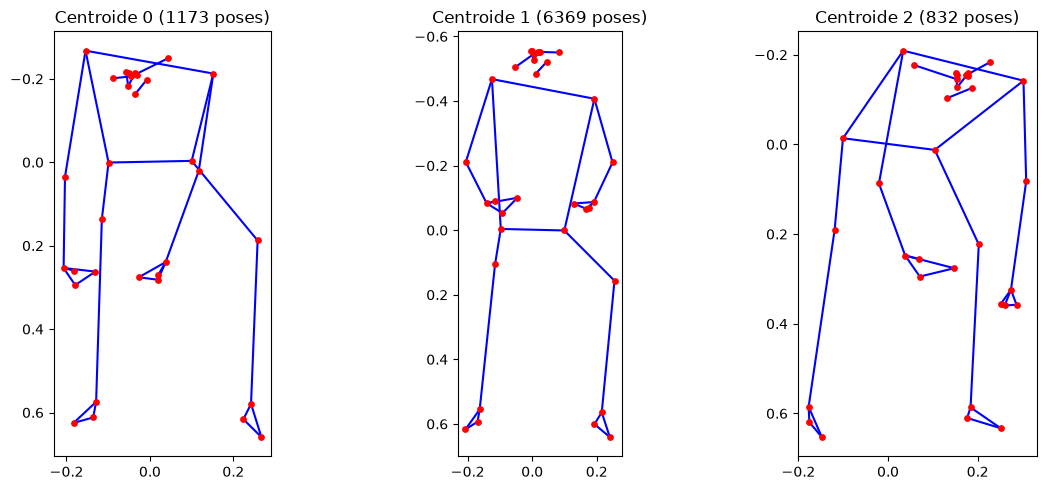

In [ ]:
K = 3
low_cost = np.inf

# Procura em 10 iterações o melhor custo
for r in range(n_runs):
    C, s = kmeans(X_norm, K, 1)
    cost = kmeans_custo(X_norm, C, s)
    if cost < low_cost:
        low_cost = cost
        C_best = C.copy()
        s_best = s.copy()

C_original = scaler.inverse_transform(C_best)   # volta às coordenadas (u, v) reais

# Cria K graficos, para K centroides
fig, axs = plt.subplots(1, K, figsize=(4*K, 5))
for k in range(K):
    n = np.sum(s_best == k)
    desenhar_pose(axs[k], C_original[k], f'Centroide {k} ({n} poses)')

plt.tight_layout()
plt.savefig('R3a_centroides.png', dpi=150)
plt.show()

### PARTE II - PCA e Redução da Dimensionalidade



R5a):n95


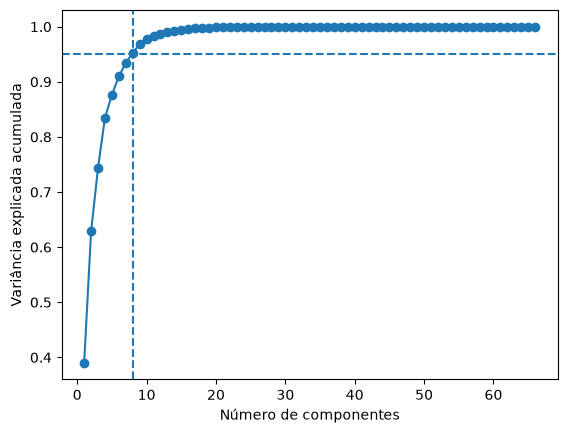

In [ ]:
pca = PCA()            # sem n_components
pca.fit(X_norm)        # calculo do pca

var_acum = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(var_acum >= 0.95) + 1
print(f'R5a):{n95}')

plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(0.95, linestyle='--')
plt.axvline(n95, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.show()